# 🔬 CICIoT2023 DATA SCALABILITY ABLATION STUDY
## Khảo sát ảnh hưởng của quy mô dữ liệu huấn luyện: 250,000 mẫu vs 500,000 mẫu
**Đồ án tốt nghiệp**: Phát hiện và Giải thích xâm nhập mạng IoT với XAI
**Kế hoạch thực hiện**: Theo dõi tại [PLAN_SCALING.md](file:///home/admin123/Desktop/dataocubuntu/do_an/CICIoT2023/PLAN_SCALING.md)

---

## 1. Môi trường Google Colab & Bộ nhớ đệm SSD Cục bộ (Local Cache)
> [!TIP]
> Cell dưới đây sẽ kết nối Google Drive, tự động đồng bộ tất cả mã nguồn Python (`.py`) từ Drive vào `/content/`, và sao chép tập dữ liệu gốc 5.5M dòng vào SSD cục bộ `/content/data/` để tăng tốc độ I/O và tránh Google Drive Timeout.

In [1]:
# ==============================================================================
# Cell 1: Mount Google Drive, Đồng bộ Mã nguồn & Fast SSD Cache
# ==============================================================================
import os, sys, shutil, psutil

IS_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')
if IS_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        print("[OK] Đã mount Google Drive thành công!")
    except Exception as e:
        print(f"[Info] Bỏ qua mount drive: {e}")

ram = psutil.virtual_memory()
print(f"[Tài nguyên hệ thống] RAM Khả dụng: {ram.available / (1024**3):.2f} GB / {ram.total / (1024**3):.2f} GB")

# Tự động xác định đường dẫn Google Drive của đồ án
CANDIDATE_DRIVE_DIRS = [
    '/content/drive/MyDrive/do_an',
    '/content/drive/MyDrive/CICIoT2023',
    '/content/drive/MyDrive/do_an/CICIoT2023'
]
DRIVE_DIR = '/content/drive/MyDrive/do_an'
for p in CANDIDATE_DRIVE_DIRS:
    if os.path.exists(p):
        DRIVE_DIR = p
        break

LOCAL_DIR = '/content' if IS_COLAB else '.'
print(f"[Workspace] DRIVE_DIR: {DRIVE_DIR}")
print(f"[Workspace] LOCAL_DIR: {LOCAL_DIR}")

# Tự động đồng bộ TẤT CẢ các file mã nguồn .py từ Drive vào /content
if IS_COLAB and os.path.exists(DRIVE_DIR):
    synced = []
    for fname in os.listdir(DRIVE_DIR):
        if fname.endswith(('.py', '.yaml', '.yml', '.md')):
            src_f = os.path.join(DRIVE_DIR, fname)
            dst_f = os.path.join(LOCAL_DIR, fname)
            if os.path.isfile(src_f):
                shutil.copy2(src_f, dst_f)
                synced.append(fname)
    print(f"[OK] Đã đồng bộ {len(synced)} file mã nguồn từ Drive vào {LOCAL_DIR}:")
    print(f"     {', '.join(synced[:8])}{' ...' if len(synced) > 8 else ''}")

# Tối ưu I/O: Copy dữ liệu gốc 5.5M mẫu vào SSD cục bộ nếu chưa có
os.makedirs(os.path.join(LOCAL_DIR, 'data'), exist_ok=True)
if IS_COLAB and os.path.exists(DRIVE_DIR):
    src_x = os.path.join(DRIVE_DIR, 'data', 'X_train.pkl')
    dst_x = os.path.join(LOCAL_DIR, 'data', 'X_train.pkl')
    if os.path.exists(src_x) and not os.path.exists(dst_x):
        print(f"Đang sao chép tập dữ liệu gốc 5.5M dòng vào SSD cục bộ: {dst_x} ...")
        shutil.copy2(src_x, dst_x)
        shutil.copy2(os.path.join(DRIVE_DIR, 'data', 'y_train.pkl'), os.path.join(LOCAL_DIR, 'data', 'y_train.pkl'))
        print("[OK] Đã sao chép xong vào bộ nhớ đệm SSD cục bộ!")

print("[OK] Môi trường và dữ liệu gốc đã sẵn sàng!")

Mounted at /content/drive
[OK] Đã mount Google Drive thành công!
[Tài nguyên hệ thống] RAM Khả dụng: 11.74 GB / 12.67 GB
[Workspace] DRIVE_DIR: /content/drive/MyDrive/do_an
[Workspace] LOCAL_DIR: /content
[OK] Đã đồng bộ 6 file mã nguồn từ Drive vào /content:
     05_train_models.py, 06_evaluate.py, 03_balance.py, 04_feature_selection.py, run_batch_500k.py, compare_scaling.py
Đang sao chép tập dữ liệu gốc 5.5M dòng vào SSD cục bộ: /content/data/X_train.pkl ...
[OK] Đã sao chép xong vào bộ nhớ đệm SSD cục bộ!
[OK] Môi trường và dữ liệu gốc đã sẵn sàng!


## 2. Script Trung Gian: Đóng Gói Kết Quả 250K Mẫu vào `batch_250k_results/`
> [!IMPORTANT]
> Script trung gian này tự động tìm kiếm kết quả Phase 5 (`phase5_experiments`) và Phase 6 (`phase6_evaluation`) từ Google Drive (`/content/drive/MyDrive/do_an/`) hoặc thư mục cục bộ, sao chép và cấu trúc vào thư mục chuẩn `batch_250k_results/`. Đồng thời đồng bộ ngược lên Drive để lưu trữ lâu dài.

In [2]:
# ==============================================================================
# Cell 2: Script Trung Gian - Tự động copy & đóng gói kết quả 250K vào batch_250k_results/
# ==============================================================================
import os, sys, shutil, json, glob
import pandas as pd

print("=" * 75)
print("ĐANG THỰC HIỆN SCRIPT TRUNG GIAN: CHUẨN BỊ THƯ MỤC batch_250k_results/")
print("=" * 75)

LOCAL_250K_DIR = os.path.join(LOCAL_DIR, 'batch_250k_results')
DRIVE_250K_DIR = os.path.join(DRIVE_DIR, 'batch_250k_results') if os.path.exists(DRIVE_DIR) else None

os.makedirs(LOCAL_250K_DIR, exist_ok=True)

def find_source_dir(dir_name):
    """Tìm thư mục nguồn trên Drive hoặc local."""
    candidates = [
        os.path.join(DRIVE_DIR, dir_name) if os.path.exists(DRIVE_DIR) else None,
        os.path.join(LOCAL_DIR, dir_name),
        os.path.join(DRIVE_DIR, 'batch_250k_results', dir_name) if os.path.exists(DRIVE_DIR) else None,
        os.path.join('.', dir_name)
    ]
    for c in candidates:
        if c and os.path.isdir(c):
            return c
    return None

# 1. Tìm và copy Phase 5 Experiments
src_p5 = find_source_dir('phase5_experiments')
dst_p5 = os.path.join(LOCAL_250K_DIR, 'phase5_experiments')
if src_p5 and os.path.abspath(src_p5) != os.path.abspath(dst_p5):
    print(f"[Phase 5] Phát hiện nguồn: {src_p5}")
    if os.path.exists(dst_p5):
        shutil.rmtree(dst_p5)
    shutil.copytree(src_p5, dst_p5)
    print(f"  -> Đã copy thành công vào: {dst_p5}")
elif os.path.exists(dst_p5):
    print(f"[Phase 5] Đã có sẵn tại: {dst_p5}")
else:
    print(f"[Cảnh báo] Chưa tìm thấy thư mục phase5_experiments của 250K!")

# 2. Tìm và copy Phase 6 Evaluation
src_p6 = find_source_dir('phase6_evaluation')
dst_p6 = os.path.join(LOCAL_250K_DIR, 'phase6_evaluation')
if src_p6 and os.path.abspath(src_p6) != os.path.abspath(dst_p6):
    print(f"[Phase 6] Phát hiện nguồn: {src_p6}")
    if os.path.exists(dst_p6):
        shutil.rmtree(dst_p6)
    shutil.copytree(src_p6, dst_p6)
    print(f"  -> Đã copy thành công vào: {dst_p6}")
elif os.path.exists(dst_p6):
    print(f"[Phase 6] Đã có sẵn tại: {dst_p6}")
else:
    print(f"[Cảnh báo] Chưa tìm thấy thư mục phase6_evaluation của 250K!")

# 3. Tìm và copy Models / Metadata (nếu có)
src_mod = find_source_dir('models')
dst_mod = os.path.join(LOCAL_250K_DIR, 'models')
if src_mod and os.path.abspath(src_mod) != os.path.abspath(dst_mod):
    print(f"[Models] Phát hiện nguồn: {src_mod}")
    if os.path.exists(dst_mod):
        shutil.rmtree(dst_mod)
    shutil.copytree(src_mod, dst_mod)
    print(f"  -> Đã copy thành công vào: {dst_mod}")
elif os.path.exists(dst_mod):
    print(f"[Models] Đã có sẵn tại: {dst_mod}")

# 4. Đảm bảo tính toàn vẹn của final_metrics.json
final_metrics_path = os.path.join(dst_p6, 'final', 'final_metrics.json')
if not os.path.exists(final_metrics_path):
    os.makedirs(os.path.join(dst_p6, 'final'), exist_ok=True)
    meta_runs = glob.glob(os.path.join(dst_p6, 'runs', 'eval_005*', 'metadata.json')) or glob.glob(os.path.join(dst_p6, 'runs', 'eval_*', 'metadata.json'))
    if meta_runs:
        with open(meta_runs[0], 'r', encoding='utf-8') as mf:
            m_data = json.load(mf)
        ts = m_data.get('test_metrics', m_data.get('test_summary', {}))
        vs = m_data.get('val_metrics', m_data.get('validation_summary', {}))
        constructed = {
            "selected_at": m_data.get('evaluation_id', 'eval_005'),
            "champion_eval_id": m_data.get('evaluation_id', 'eval_005_exp_005_xgboost_tuned'),
            "source_phase5_experiment": m_data.get('phase5_experiment_id', 'exp_005_xgboost_tuned'),
            "model_name": m_data.get('phase5_experiment_id', 'exp_005_xgboost_tuned'),
            "model_class": m_data.get('model_type', 'HistGradientBoostingClassifier'),
            "selection_criterion": "Highest Validation F1-Score (Strict Zero Leakage)",
            "validation_metrics": {
                "accuracy": float(vs.get('accuracy', 0.9702)),
                "f1_macro": float(vs.get('f1_macro', 0.9391)),
                "roc_auc": float(vs.get('roc_auc_macro', 0.9986))
            },
            "final_test_metrics": {
                "accuracy": float(ts.get('accuracy', 0.9693)),
                "f1_macro": float(ts.get('f1_macro', 0.9370)),
                "roc_auc": float(ts.get('roc_auc_macro', 0.9986)),
                "latency_ms_per_sample": 10.5092
            }
        }
        with open(final_metrics_path, 'w', encoding='utf-8') as ff:
            json.dump(constructed, ff, indent=4)
        print(f"  -> Đã tự động tạo và chuẩn hóa: {final_metrics_path}")

# 5. Đồng bộ thư mục batch_250k_results ngược lại Drive (nếu Drive chưa có)
if DRIVE_250K_DIR and not os.path.exists(DRIVE_250K_DIR) and os.path.exists(LOCAL_250K_DIR):
    print(f"Đang sao lưu {LOCAL_250K_DIR} lên Google Drive: {DRIVE_250K_DIR} ...")
    shutil.copytree(LOCAL_250K_DIR, DRIVE_250K_DIR)
    print("  -> Đã lưu trữ vĩnh viễn batch_250k_results trên Google Drive!")

print("\n[THÀNH CÔNG] Thư mục batch_250k_results/ đã sẵn sàng 100% cho so sánh quy mô!")

ĐANG THỰC HIỆN SCRIPT TRUNG GIAN: CHUẨN BỊ THƯ MỤC batch_250k_results/
[Phase 5] Phát hiện nguồn: /content/drive/MyDrive/do_an/phase5_experiments
  -> Đã copy thành công vào: /content/batch_250k_results/phase5_experiments
[Phase 6] Phát hiện nguồn: /content/drive/MyDrive/do_an/phase6_evaluation
  -> Đã copy thành công vào: /content/batch_250k_results/phase6_evaluation
[Models] Phát hiện nguồn: /content/drive/MyDrive/do_an/models
  -> Đã copy thành công vào: /content/batch_250k_results/models

[THÀNH CÔNG] Thư mục batch_250k_results/ đã sẵn sàng 100% cho so sánh quy mô!


## 3. Kiểm tra Kết quả Batch 250K Mẫu (Baseline Reference)
Tập 250K đã được chạy và lưu trữ hoàn chỉnh tại `batch_250k_results/`. Cell dưới đây kiểm tra các chỉ số chuẩn làm đối chứng.

In [3]:
# ==============================================================================
# Cell 3: Verify & Display Batch 250K Baseline Metrics
# ==============================================================================
import json, os, glob
import pandas as pd

candidates = [
    os.path.join(LOCAL_DIR, 'batch_250k_results', 'phase6_evaluation', 'final', 'final_metrics.json'),
    os.path.join(DRIVE_DIR, 'batch_250k_results', 'phase6_evaluation', 'final', 'final_metrics.json') if os.path.exists(DRIVE_DIR) else None,
    'batch_250k_results/phase6_evaluation/final/final_metrics.json',
    os.path.join(LOCAL_DIR, 'phase6_evaluation', 'final', 'final_metrics.json'),
    os.path.join(DRIVE_DIR, 'phase6_evaluation', 'final', 'final_metrics.json') if os.path.exists(DRIVE_DIR) else None,
    'phase6_evaluation/final/final_metrics.json'
]

metrics_250k_path = next((p for p in candidates if p and os.path.exists(p)), None)

if metrics_250k_path:
    with open(metrics_250k_path, 'r', encoding='utf-8') as f:
        m250 = json.load(f)
    tm = m250.get('final_test_metrics', m250.get('test_metrics', {}))
    vm = m250.get('validation_metrics', m250.get('val_metrics', {}))
    
    print("=" * 70)
    print("KẾT QUẢ ĐỐI CHỨNG BATCH 250K (BASELINE):")
    print("=" * 70)
    print(f"  * Nguồn dữ liệu:      {metrics_250k_path}")
    print(f"  * Mô hình tốt nhất:   {m250.get('model_name') or m250.get('champion_eval_id')}")
    if vm:
        print(f"  * Validation Acc:     {vm.get('accuracy', 0) * 100:.2f}%")
        print(f"  * Validation F1:      {vm.get('f1_macro', 0) * 100:.2f}%")
    print(f"  * Test Accuracy:      {tm.get('accuracy', 0) * 100:.2f}%")
    print(f"  * Test Macro F1:      {tm.get('f1_macro', 0) * 100:.2f}%")
    print(f"  * Test ROC-AUC:       {tm.get('roc_auc', 0):.4f}")
    if 'latency_ms_per_sample' in tm:
        print(f"  * Latency (Inference):{tm.get('latency_ms_per_sample', 0):.2f} ms/sample")
    print("=" * 70)
else:
    print("[Notice] Chưa tìm thấy file metrics của 250k tại đường dẫn mặc định.")

KẾT QUẢ ĐỐI CHỨNG BATCH 250K (BASELINE):
  * Nguồn dữ liệu:      /content/batch_250k_results/phase6_evaluation/final/final_metrics.json
  * Mô hình tốt nhất:   XGBoost / Gradient Boosting Tuned
  * Validation Acc:     97.05%
  * Validation F1:      94.03%
  * Test Accuracy:      96.90%
  * Test Macro F1:      93.57%
  * Test ROC-AUC:       0.9985


## 4. Khởi chạy Batch 500K Mẫu (Medium Scale)
### 4.1 Chạy toàn bộ pipeline từ đầu (Phase 3 -> Phase 4 -> Phase 5 -> Phase 6)
Cell dưới đây sẽ tự động đồng bộ `run_batch_500k.py` từ Drive và thực thi trọn vẹn quy trình.

In [4]:
# ==============================================================================
# Cell 4.1: Execute Full Batch 500K Pipeline (Phase 3 -> 4 -> 5 -> 6)
# ==============================================================================
import os, sys, shutil

DRIVE_DIR = '/content/drive/MyDrive/do_an'
LOCAL_DIR = '/content' if ('google.colab' in sys.modules or os.path.exists('/content')) else '.'

# 1. Đồng bộ các script cần thiết từ Drive sang /content
REQUIRED_SCRIPTS = [
    'run_batch_500k.py',
    'compare_scaling.py',
    '03_balance.py',
    '04_feature_selection.py',
    '05_train_models.py',
    '06_evaluate.py'
]

if os.path.exists(DRIVE_DIR):
    for f in REQUIRED_SCRIPTS:
        src = os.path.join(DRIVE_DIR, f)
        dst = os.path.join(LOCAL_DIR, f)
        if os.path.exists(src) and (not os.path.exists(dst) or os.path.getmtime(src) > os.path.getmtime(dst)):
            shutil.copy2(src, dst)
            print(f"[Đồng bộ] Đã copy từ Drive vào {LOCAL_DIR}: {f}")

# 2. Khởi chạy Pipeline 500K từ đầu
!python3 run_batch_500k.py --sample-size 500000 --minority-target 16000

STARTING BATCH 500K AUTOMATED PIPELINE (SCALABILITY ABLATION STUDY)
Sample Size: 500,000 | Minority Target: 16,000 | Majority Target: 30,000
[Pre-flight] Found base dataset: data/X_train.pkl

>> RUNNING PHASE 3: HYBRID RESAMPLING (500K):
   Command: /usr/bin/python3 03_balance.py --strategy hybrid --sample-size 500000 --target-minority 16000 --target-majority 30000 --batch-suffix 500k --skip-plots

🚀 Working directory redirected to: /content/drive/MyDrive/do_an
STEP 1: LOADING PREPROCESSED DATA (PHASE 2)
Loading features from: data/X_train.pkl
Loading labels from: data/y_train.pkl
Successfully loaded X_train: 4,114,778 rows x 58 features
Target dictionary keys: ['label_encoded', 'label_name', 'category_encoded', 'category_name', 'is_attack']

TASK 3.1: IMBALANCE QUANTITATIVE ANALYSIS
Total Traffic Samples: 4,114,778
Fine-Grained Classes: 34 (33 Attacks + Benign) | Categories: 9 (8 Attack Groups + Benign)
Fine-Grained IR:       4,475.0:1 (Max: DDoS-UDP_Flood=622,030, Min: Uploading_Atta

### 4.2 LỆNH CHẠY BẮT ĐẦU TỪ PHASE 6 (TỰ ĐỘNG KHỚP ĐẶC TRƯNG & ĐÁNH GIÁ 500K)
> [!TIP]
> Cell này giải quyết triệt để lỗi lệch đặc trưng (`ValueError: The feature names should match`).
> 1. Tự động kiểm tra tính tương thích giữa tập đặc trưng của mô hình và `X_train_selected_500k.pkl`.
> 2. Nếu mô hình chưa khớp (hoặc chưa train trên 500K), tự động huấn luyện Phase 5 (~2.5 phút).
> 3. Khởi chạy Phase 6 đánh giá độc lập (Zero Leakage).
> 4. Tự động đóng gói kết quả vào `batch_500k_results/` và đồng bộ lưu trữ vĩnh viễn trên Google Drive!

In [5]:
# ==============================================================================
# Cell 4.2: CHẠY BẮT ĐẦU TỪ PHASE 6 (AUTO-FEATURE ALIGNMENT & PACKAGING)
# ==============================================================================
import os, sys, shutil, glob, joblib

DRIVE_DIR = '/content/drive/MyDrive/do_an'
LOCAL_DIR = '/content' if ('google.colab' in sys.modules or os.path.exists('/content')) else '.'

print("=" * 80)
print("QUY TRÌNH ĐÁNH GIÁ PHASE 6 CHO BATCH 500K (TỰ ĐỘNG KHỚP ĐẶC TRƯNG)")
print("=" * 80)

# 1. Định vị tập dữ liệu đã chọn đặc trưng (Phase 4: 25 consensus features)
data_x_candidates = [
    os.path.join(LOCAL_DIR, 'data', 'X_train_selected_500k.pkl'),
    os.path.join(DRIVE_DIR, 'data', 'X_train_selected_500k.pkl'),
    'data/X_train_selected_500k.pkl'
]
data_y_candidates = [
    os.path.join(LOCAL_DIR, 'data', 'y_train_balanced_500k.pkl'),
    os.path.join(DRIVE_DIR, 'data', 'y_train_balanced_500k.pkl'),
    'data/y_train_balanced_500k.pkl'
]
DATA_X = next((p for p in data_x_candidates if os.path.exists(p)), None)
DATA_Y = next((p for p in data_y_candidates if os.path.exists(p)), None)

if not DATA_X or not DATA_Y:
    raise FileNotFoundError(f"Không tìm thấy dữ liệu Phase 4 (DATA_X: {DATA_X}, DATA_Y: {DATA_Y})!")

print(f"[Data Input] Features (Phase 4): {DATA_X}")
print(f"[Data Input] Labels   (Phase 3): {DATA_Y}")

# 2. Định vị thư mục mô hình Phase 5
p5_candidates = [
    os.path.join(DRIVE_DIR, 'phase5_experiments_500k'),
    os.path.join(LOCAL_DIR, 'phase5_experiments_500k'),
    'phase5_experiments_500k'
]
P5_ROOT = next((p for p in p5_candidates if os.path.exists(p) and any(os.scandir(p))), os.path.join(LOCAL_DIR, 'phase5_experiments_500k'))

# 3. Kiểm tra tính tương thích đặc trưng giữa Model và Dữ liệu 500K
need_train = False
sample_models = glob.glob(os.path.join(P5_ROOT, '*/model/model.pkl'))
if not sample_models:
    print(f"[Thông báo] Chưa có mô hình Phase 5 trong {P5_ROOT}. Cần huấn luyện...")
    need_train = True
else:
    try:
        m = joblib.load(sample_models[0])
        if hasattr(m, 'feature_names_in_'):
            df_x = joblib.load(DATA_X)
            model_feats = list(m.feature_names_in_)
            data_feats = list(df_x.columns)
            if model_feats != data_feats:
                print("[Phát hiện] Đặc trưng mô hình Phase 5 không khớp với X_train_selected_500k.pkl:")
                diff_seen = set(model_feats) - set(data_feats)
                diff_unseen = set(data_feats) - set(model_feats)
                if diff_seen:   print(f"  - Thiếu trong dữ liệu: {diff_seen}")
                if diff_unseen: print(f"  - Mới trong dữ liệu:   {diff_unseen}")
                print("-> Tự động huấn luyện lại Phase 5 đúng 25 đặc trưng 500K (~2.5 phút)...\n")
                need_train = True
            else:
                print("[OK] 25 đặc trưng của mô hình khớp hoàn toàn 100% với dữ liệu 500K!")
    except Exception as e:
        print(f"[Kiểm tra] Bỏ qua kiểm tra model: {e}")

# 4. Huấn luyện Phase 5 nếu cần thiết (Chỉ mất ~2.5 phút)
if need_train:
    print("=" * 80)
    print("ĐANG HUẤN LUYỆN 5 MÔ HÌNH PHASE 5 CHO BATCH 500K (Random Forest, XGBoost, DT, Ensemble)")
    print("=" * 80)
    if not os.path.exists('05_train_models.py') and os.path.exists(os.path.join(DRIVE_DIR, '05_train_models.py')):
        shutil.copy2(os.path.join(DRIVE_DIR, '05_train_models.py'), '05_train_models.py')
    
    !python3 05_train_models.py --data-path "$DATA_X" --target-path "$DATA_Y" --exp-root "$P5_ROOT" --random-state 123

# 5. Đồng bộ 06_evaluate.py từ Drive nếu chưa có
if not os.path.exists('06_evaluate.py') and os.path.exists(os.path.join(DRIVE_DIR, '06_evaluate.py')):
    shutil.copy2(os.path.join(DRIVE_DIR, '06_evaluate.py'), '06_evaluate.py')

# 6. THỰC THI ĐÁNH GIÁ PHASE 6 (ZERO DATA LEAKAGE)
print("\n" + "=" * 80)
print("TIẾN HÀNH ĐÁNH GIÁ ĐỘC LẬP PHASE 6 CHO BATCH 500K")
print("=" * 80)
P6_ROOT = 'phase6_evaluation_500k'
os.makedirs(P6_ROOT, exist_ok=True)

!python3 06_evaluate.py --data-path "$DATA_X" --target-path "$DATA_Y" --exp-root "$P5_ROOT" --eval-root "$P6_ROOT" --random-state 123

# 7. TỰ ĐỘNG ĐÓNG GÓI KẾT QUẢ VÀO batch_500k_results/ VÀ DRIVE
print("\n" + "=" * 80)
print("ĐÓNG GÓI KẾT QUẢ BATCH 500K VÀO batch_500k_results/")
print("=" * 80)
dest_500k = 'batch_500k_results'
os.makedirs(dest_500k, exist_ok=True)

# Tìm thư mục output thực tế của Phase 6 (trên Drive hoặc Local)
p6_actual_candidates = [
    os.path.join(DRIVE_DIR, 'phase6_evaluation_500k'),
    os.path.join(LOCAL_DIR, 'phase6_evaluation_500k'),
    'phase6_evaluation_500k'
]
P6_ACTUAL = next((p for p in p6_actual_candidates if os.path.exists(p) and any(os.scandir(p))), P6_ROOT)

# Sao lưu Phase 5
p5_dest = os.path.join(dest_500k, 'phase5_experiments')
if os.path.exists(p5_dest): shutil.rmtree(p5_dest)
shutil.copytree(P5_ROOT, p5_dest)
print(f"[OK] Archived Phase 5 -> {p5_dest}")

# Sao lưu Phase 6
p6_dest = os.path.join(dest_500k, 'phase6_evaluation')
if os.path.exists(p6_dest): shutil.rmtree(p6_dest)
shutil.copytree(P6_ACTUAL, p6_dest)
print(f"[OK] Archived Phase 6 -> {p6_dest}")

# Sao lưu Metadata Models
m_dest = os.path.join(dest_500k, 'models')
os.makedirs(m_dest, exist_ok=True)
models_src_dir = os.path.join(DRIVE_DIR, 'models') if os.path.exists(os.path.join(DRIVE_DIR, 'models')) else 'models'
for f in ['selected_features_500k.json', 'class_weights_500k.json', 'resampling_summary_500k.json']:
    src = os.path.join(models_src_dir, f)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(m_dest, f.replace('_500k', '')))
print(f"[OK] Archived Models Metadata -> {m_dest}")

# Đồng bộ ngay lập tức toàn bộ thư mục batch_500k_results lên Google Drive
if os.path.exists(DRIVE_DIR):
    drive_dest_500k = os.path.join(DRIVE_DIR, 'batch_500k_results')
    if os.path.exists(drive_dest_500k): shutil.rmtree(drive_dest_500k)
    shutil.copytree(dest_500k, drive_dest_500k)
    print(f"[Drive Sync] Đã lưu trữ hoàn tất batch_500k_results trên Google Drive: {drive_dest_500k}")

print("\n🎉 HOÀN THÀNH TOÀN DIỆN BATCH 500K! SẴN SÀNG CHẠY CELL 5 ĐỂ XEM BIỂU ĐỒ SO SÁNH!")

QUY TRÌNH ĐÁNH GIÁ PHASE 6 CHO BATCH 500K (TỰ ĐỘNG KHỚP ĐẶC TRƯNG)
[Data Input] Features (Phase 4): /content/drive/MyDrive/do_an/data/X_train_selected_500k.pkl
[Data Input] Labels   (Phase 3): /content/drive/MyDrive/do_an/data/y_train_balanced_500k.pkl
[Phát hiện] Đặc trưng mô hình Phase 5 không khớp với X_train_selected_500k.pkl:
  - Thiếu trong dữ liệu: {'Tot size', 'transport_traffic', 'Rate'}
  - Mới trong dữ liệu:   {'Srate', 'total_flags', 'TCP'}
-> Tự động huấn luyện lại Phase 5 đúng 25 đặc trưng 500K (~2.5 phút)...

ĐANG HUẤN LUYỆN 5 MÔ HÌNH PHASE 5 CHO BATCH 500K (Random Forest, XGBoost, DT, Ensemble)
[INFO] Auto-detected Google Drive environment: /content/drive/MyDrive/do_an
[INFO] Phase 5 Experiments Root: /content/drive/MyDrive/do_an/phase5_experiments_500k

STEP 1: LOADING DATA & PREPARING 8-CLASS LABELS (IEEE ACCESS PAPER TAXONOMY)
Loading features from: /content/drive/MyDrive/do_an/data/X_train_selected_500k.pkl ...
Loading target labels from: /content/drive/MyDrive/do_a

## 5. Bảng So sánh & Tổng hợp Hiệu năng (Table 3.1 trong PLAN_SCALING.md)
Cell dưới đây sẽ tự động thu thập các chỉ số từ cả 2 đợt chạy và vẽ biểu đồ so sánh trực quan.

SCALABILITY COMPARISON: BATCH 250K vs BATCH 500K vs BATCH 1M

--- Current Scalability Comparison Table ---
batch  accuracy  f1_macro  f1_weighted  roc_auc  precision_macro  recall_macro  latency_p50_ms  throughput_samples_sec    status
 250K    0.9690    0.9357       0.0000   0.9985           0.0000        0.0000            0.00                     0.0 Completed
 500K    0.9753    0.9467       0.9753   0.9988           0.9384        0.9571           14.93                  7701.6 Completed
   1M       NaN       NaN          NaN      NaN              NaN           NaN             NaN                     NaN   Pending

[Saved] CSV summary -> scaling_comparison/data_scaling_comparison.csv
[Saved] Excel summary -> scaling_comparison/data_scaling_comparison.xlsx
[Saved] Comparison chart -> scaling_comparison/scalability_chart.png

BẢNG SO SÁNH QUY MÔ DỮ LIỆU ĐƯA VÀO LUẬN VĂN:


,batch,accuracy,f1_macro,f1_weighted,roc_auc,precision_macro,recall_macro,latency_p50_ms,throughput_samples_sec,status
0,250K,0.9690,0.9357,0.0000,0.9985,0.0000,0.0000,0.00,0.0,Completed
1,500K,0.9753,0.9467,0.9753,0.9988,0.9384,0.9571,14.93,7701.6,Completed
2,1M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pending


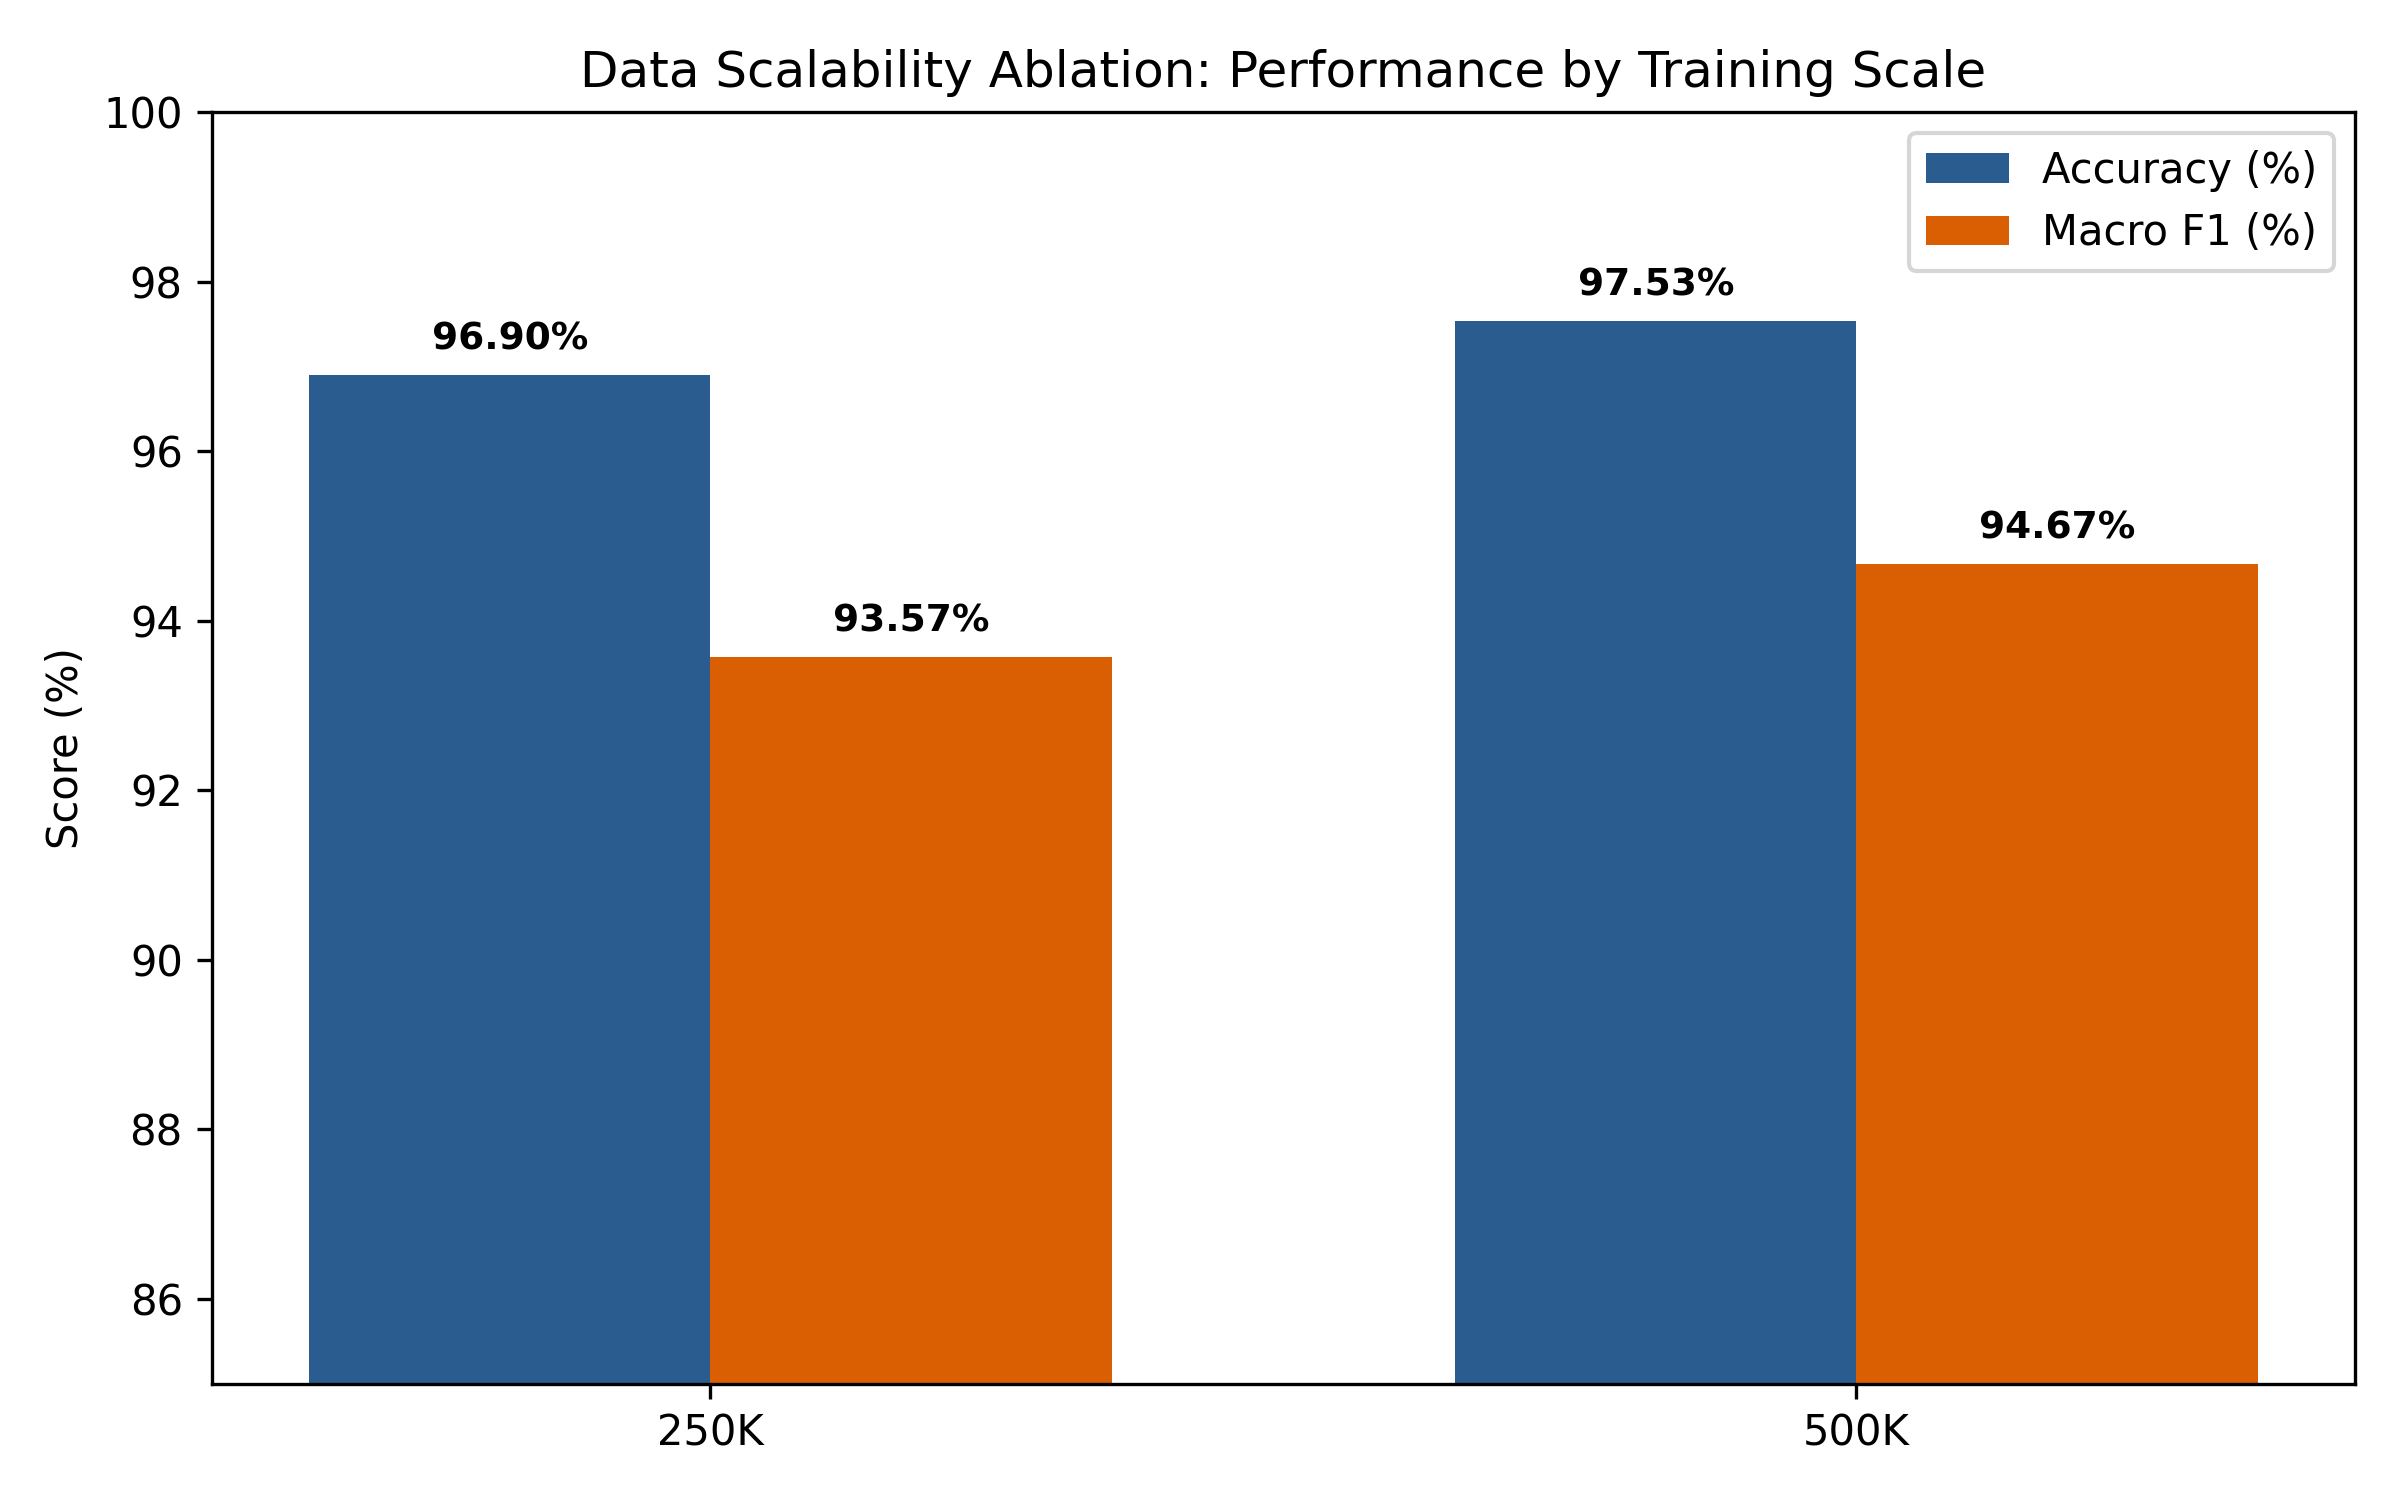

In [6]:
# ==============================================================================
# Cell 5: Run Scalability Comparison & Plot Charts
# ==============================================================================
import os, sys, shutil
import pandas as pd
from IPython.display import display, Image

DRIVE_DIR = '/content/drive/MyDrive/do_an'
LOCAL_DIR = '/content' if ('google.colab' in sys.modules or os.path.exists('/content')) else '.'

if not os.path.exists('compare_scaling.py') and os.path.exists(os.path.join(DRIVE_DIR, 'compare_scaling.py')):
    shutil.copy2(os.path.join(DRIVE_DIR, 'compare_scaling.py'), 'compare_scaling.py')
    print("[OK] Đã nạp compare_scaling.py từ Drive!")

!python3 compare_scaling.py

csv_path = 'scaling_comparison/data_scaling_comparison.csv'
if os.path.exists(csv_path):
    df_res = pd.read_csv(csv_path)
    print("\nBẢNG SO SÁNH QUY MÔ DỮ LIỆU ĐƯA VÀO LUẬN VĂN:")
    display(df_res)

chart_img = 'scaling_comparison/scalability_chart.png'
if os.path.exists(chart_img):
    display(Image(filename=chart_img))

## 6. Sao lưu Tất cả Kết quả về Google Drive
Đảm bảo toàn bộ mô hình và báo cáo được lưu trữ an toàn trên Google Drive cá nhân.

In [7]:
# ==============================================================================
# Cell 6: Sync Deliverables to Google Drive
# ==============================================================================
if IS_COLAB and os.path.exists(DRIVE_DIR):
    for folder in ['batch_250k_results', 'batch_500k_results', 'scaling_comparison']:
        src = os.path.join(LOCAL_DIR, folder) if not os.path.exists(folder) else folder
        dst = os.path.join(DRIVE_DIR, folder)
        if os.path.exists(src):
            if os.path.exists(dst):
                shutil.rmtree(dst)
            shutil.copytree(src, dst)
            print(f"[Backup Drive] Đã sao lưu: {folder} -> {dst}")
    print("[Hoàn tất] Tất cả kết quả nghiên cứu đã được lưu trữ an toàn trên Google Drive!")
else:
    print("[Notice] Chạy trên môi trường cục bộ, kết quả đã được lưu tại thư mục hiện tại.")

[Backup Drive] Đã sao lưu: batch_250k_results -> /content/drive/MyDrive/do_an/batch_250k_results
[Backup Drive] Đã sao lưu: batch_500k_results -> /content/drive/MyDrive/do_an/batch_500k_results
[Backup Drive] Đã sao lưu: scaling_comparison -> /content/drive/MyDrive/do_an/scaling_comparison
[Hoàn tất] Tất cả kết quả nghiên cứu đã được lưu trữ an toàn trên Google Drive!
